# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faheem-danish/internship-starter-1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import hf_hub_download

# Load Hugging Face token
token = userdata.get("HF_TOKEN")
print("Token loaded:", token is not None)

# Download March data
march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=token
)

march_df = pd.read_parquet(march_file)

print("Shape:", march_df.shape)
print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

Token loaded: True


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Shape: (9841378, 30)
Date range: 2026-03-01 to 2026-03-31


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*
### Ranked action approach

The action queue prioritizes content items for human refresh review using the transparent Week-4 baseline. An item is eligible when it has at least 500 impressions and an average position of 11 or worse.

The priority score gives more weight to pages with higher observed impressions because they represent a larger search-visibility opportunity. Pages with an average position of 21 or worse receive an additional position factor.

The reason code `visible_position_opportunity` explains why an item entered the review queue. The queue is decision-support only: a high rank does not mean that a page must be refreshed.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Create the content-level decision table from the March data

df = march_df.copy()

df["impressions"] = pd.to_numeric(
    df["gsc_impressions"],
    errors="coerce"
).fillna(0)

df["clicks"] = pd.to_numeric(
    df["gsc_clicks"],
    errors="coerce"
).fillna(0)

df["avg_position"] = pd.to_numeric(
    df["gsc_avg_position"],
    errors="coerce"
)

# One row per client + content item for the March window
content_df = (
    df
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        avg_position=("avg_position", "mean")
    )
)

# Calculate content-level CTR
content_df["ctr_pct"] = np.where(
    content_df["impressions"] > 0,
    content_df["clicks"] / content_df["impressions"] * 100,
    0
)

print("Total content items:", len(content_df))
print("Unique clients:", content_df["client_hash_id"].nunique())

# Recreate the Week-4 transparent baseline

content_df["eligible"] = (
    (content_df["impressions"] >= 500) &
    (content_df["avg_position"] >= 11)
)

# Position opportunity factor
content_df["position_factor"] = np.where(
    content_df["avg_position"] >= 21,
    1.5,
    1.0
)

# Transparent priority score
content_df["score"] = (
    content_df["impressions"] *
    content_df["position_factor"]
)

# Reason code
content_df["reason_code"] = np.where(
    content_df["eligible"],
    "visible_position_opportunity",
    "not_eligible"
)

# Action
content_df["action"] = np.where(
    content_df["eligible"],
    "refresh_review",
    "no_action"
)

# Build ranked queue
queue = (
    content_df[content_df["eligible"]]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)

print("Total content items:", len(content_df))
print("Selected for refresh review:", len(queue))
print("Top score:", round(queue["score"].max(), 2))

display(
    queue[
        [
            "rank",
            "content_hash_id",
            "impressions",
            "clicks",
            "avg_position",
            "ctr_pct",
            "score",
            "reason_code",
            "action"
        ]
    ].head(20)
)


Total content items: 331437
Unique clients: 55
Total content items: 331437
Selected for refresh review: 21143
Top score: 291868.5


,rank,content_hash_id,impressions,clicks,avg_position,ctr_pct,score,reason_code,action
0,1,content_36e53e9c707674fc,194579,242,32.766674,0.124371,291868.5,visible_position_opportunity,refresh_review
1,2,content_e8a52cf3d5988c07,244931,669,15.008339,0.273138,244931.0,visible_position_opportunity,refresh_review
2,3,content_82e35c4845e6c391,143907,60,22.558608,0.041694,215860.5,visible_position_opportunity,refresh_review
3,4,content_3df3f32f3fd58dea,140156,197,23.335465,0.140558,210234.0,visible_position_opportunity,refresh_review
4,5,content_df47d1b976106de4,131707,163,24.355625,0.123760,197560.5,visible_position_opportunity,refresh_review
5,6,content_bdf60c86117079be,112429,12,30.769353,0.010673,168643.5,visible_position_opportunity,refresh_review
6,7,content_661a7734f691bef5,110424,73,23.888656,0.066109,165636.0,visible_position_opportunity,refresh_review
7,8,content_cae701a83cad5e36,98572,242,23.730705,0.245506,147858.0,visible_position_opportunity,refresh_review
8,9,content_559cdd76da9306de,97378,2,36.712074,0.002054,146067.0,visible_position_opportunity,refresh_review
9,10,content_9fff53e827550f9d,94673,475,22.469914,0.501727,142009.5,visible_position_opportunity,refresh_review


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
### Intended use

This playbook is intended for content strategists or SEO reviewers who need a ranked shortlist of content items for manual refresh review.

The queue uses observed March 2026 search-performance signals to prioritize attention. It is intended as decision-support rather than an automatic content publishing or deletion system.

### Limits

The queue does not directly observe content quality, search intent, business importance, conversion value, editorial constraints, or the actual outcome of a content refresh.

The earlier modeling target was derived from the Week-4 eligibility rule, so model agreement with that rule should not be interpreted as evidence that a refresh will improve rankings, traffic, or conversions.

The current analysis uses a March 2026 decision window. A single monthly snapshot is not sufficient to establish long-term content decay or seasonal behavior. Therefore, these recommendations are directional and should be reviewed by a human.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Basic scope checks for the action playbook

print("Decision window: March 2026")
print("Content items:", len(content_df))
print("Refresh candidates:", len(queue))
print(
    "Eligibility rate:",
    round(content_df["eligible"].mean(), 4)
)
print(
    "Unique clients:",
    content_df["client_hash_id"].nunique()
)

Decision window: March 2026
Content items: 331437
Refresh candidates: 21143
Eligibility rate: 0.0638
Unique clients: 55


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
### Human review rules

Before approving a refresh recommendation, a reviewer should check:

1. Whether the page matches the intended search intent.
2. Whether the topic is still relevant.
3. Whether the page has useful content that can realistically be improved.
4. Whether important information could be lost during a refresh.
5. Whether technical issues could explain the observed performance.
6. Whether internal linking or indexing issues should be addressed first.
7. Whether the page has strategic or business importance that is not represented by search impressions.

The ranked queue is therefore a shortlist for investigation, not a direct instruction to edit a page.

### No-go list

The system should not automatically:

- publish rewritten content;
- delete pages;
- redirect pages;
- change canonical URLs;
- change important metadata without review;
- remove content because of low impressions alone;
- declare a page unsuccessful from one monthly snapshot;
- make business or editorial decisions from the score alone.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Show the action distribution that requires human review

action_summary = (
    queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

display(action_summary)

,action,count
0,refresh_review,21143


### Archetype-to-action mapping

The archetypes below describe observed search-performance patterns. They do not claim that the underlying content is good or bad. Their purpose is to help a reviewer decide what to investigate first.

In [8]:
def assign_archetype(row):
    if row["impressions"] >= 5000 and row["avg_position"] >= 21:
        return "high_visibility_low_position"
    elif row["impressions"] >= 5000 and row["avg_position"] >= 11:
        return "high_visibility_mid_position"
    elif row["impressions"] >= 500 and row["avg_position"] >= 21:
        return "moderate_visibility_low_position"
    elif row["impressions"] >= 500 and row["avg_position"] >= 11:
        return "moderate_visibility_mid_position"
    else:
        return "below_review_threshold"


queue["archetype"] = queue.apply(
    assign_archetype,
    axis=1
)

archetype_actions = pd.DataFrame({
    "archetype": [
        "high_visibility_low_position",
        "high_visibility_mid_position",
        "moderate_visibility_low_position",
        "moderate_visibility_mid_position"
    ],
    "recommended_action": [
        "Priority refresh review",
        "Refresh review",
        "Targeted refresh review",
        "Secondary refresh review"
    ],
    "review_focus": [
        "Check intent, topical coverage, internal links, and competitive gaps.",
        "Check whether stronger content coverage could improve visibility.",
        "Check relevance and missing topic coverage before investing effort.",
        "Review if strategic value justifies the effort."
    ]
})

display(archetype_actions)

,archetype,recommended_action,review_focus
0,high_visibility_low_position,Priority refresh review,"Check intent, topical coverage, internal links..."
1,high_visibility_mid_position,Refresh review,Check whether stronger content coverage could ...
2,moderate_visibility_low_position,Targeted refresh review,Check relevance and missing topic coverage bef...
3,moderate_visibility_mid_position,Secondary refresh review,Review if strategic value justifies the effort.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
### Monitoring triggers

The playbook should be reviewed when the underlying data or recommendation quality changes materially.

Useful monitoring signals include:

- sustained changes in the distribution of impressions;
- sustained changes in average position;
- a large change in the percentage of eligible content;
- changes in the number of clients or content items;
- evidence that high-ranked recommendations are no longer useful to human reviewers;
- availability of additional monthly history that could support a stronger content-decay analysis.

A retraining or rule-review decision should be based on measured changes rather than complexity or a fixed calendar alone.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_summary = pd.DataFrame([{
    "decision_window": "2026-03",
    "content_items": len(content_df),
    "refresh_candidates": len(queue),
    "eligibility_rate": round(
        content_df["eligible"].mean(), 4
    ),
    "unique_clients": content_df["client_hash_id"].nunique(),
    "median_impressions": content_df["impressions"].median(),
    "median_avg_position": content_df["avg_position"].median()
}])

display(monitoring_summary)

,decision_window,content_items,refresh_candidates,eligibility_rate,unique_clients,median_impressions,median_avg_position
0,2026-03,331437,21143,0.0638,55,2.0,8.505296


### Decay / refresh insight

The March 2026 snapshot identifies pages with observed visibility and position opportunities, but it does not provide enough longitudinal history to measure true content decay.

Therefore, this playbook does not claim that the ranked pages are decaying.

A stronger future analysis would compare the same content items across multiple months and monitor sustained changes in impressions, clicks, CTR, and average position. Sustained negative trends would provide stronger evidence for a refresh recommendation than a single-month snapshot.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*
### Paper-ready exports

The ranked queue is exported so that the research paper can trace its recommendations back to the notebook output.

The metrics JSON records the main measured quantities used by the playbook. A reusable figure is also saved under `work/figures/`.

The queue CSV is generated by the notebook and is intentionally kept out of Git according to the assignment's data-leak guard.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Output directories ready.")


Output directories ready.


In [11]:
queue_export = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "avg_position",
        "ctr_pct",
        "score",
        "archetype",
        "reason_code",
        "action"
    ]
].copy()

queue_path = "work/outputs/content_action_queue.csv"

queue_export.to_csv(
    queue_path,
    index=False
)

print("Queue exported:", queue_path)
print("Rows exported:", len(queue_export))

Queue exported: work/outputs/content_action_queue.csv
Rows exported: 21143


In [12]:
metrics = {
    "decision_window": "2026-03",
    "total_content_items": int(len(content_df)),
    "refresh_candidates": int(len(queue)),
    "eligibility_rate": round(
        float(content_df["eligible"].mean()),
        4
    ),
    "unique_clients": int(
        content_df["client_hash_id"].nunique()
    ),
    "top_score": round(
        float(queue["score"].max()),
        2
    ),
    "reason_code": "visible_position_opportunity",
    "method": "transparent Week-4 rule",
    "important_limitation": (
        "The March snapshot supports directional "
        "decision-support prioritization, not causal "
        "claims about refresh success."
    )
}

metrics_path = (
    "work/outputs/w07_action_playbook_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved:", metrics_path)

Metrics saved: work/outputs/w07_action_playbook_metrics.json


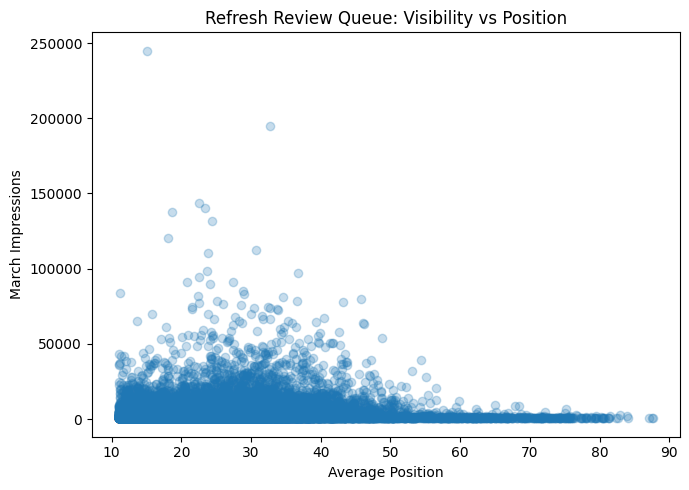

Figure saved: work/figures/refresh_queue_visibility_position.png


In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    queue["avg_position"],
    queue["impressions"],
    alpha=0.25
)

plt.xlabel("Average Position")
plt.ylabel("March Impressions")
plt.title("Refresh Review Queue: Visibility vs Position")

plt.tight_layout()

figure_path = (
    "work/figures/refresh_queue_visibility_position.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path)

In [14]:
print("=== EXPORT CHECK ===")

print(
    "Queue exists:",
    os.path.exists("work/outputs/content_action_queue.csv")
)

print(
    "Metrics exists:",
    os.path.exists(
        "work/outputs/w07_action_playbook_metrics.json"
    )
)

print(
    "Figure exists:",
    os.path.exists(
        "work/figures/refresh_queue_visibility_position.png"
    )
)

print("\nQueue shape:", queue_export.shape)
print(
    "Queue columns:",
    queue_export.columns.tolist()
)

=== EXPORT CHECK ===
Queue exists: True
Metrics exists: True
Figure exists: True

Queue shape: (21143, 11)
Queue columns: ['rank', 'client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'avg_position', 'ctr_pct', 'score', 'archetype', 'reason_code', 'action']


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.